# Setup

## Libraries Loading

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown


# Models
from sklearn.ensemble import RandomForestClassifier
# make_scorer source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html
from sklearn.metrics import confusion_matrix, make_scorer, roc_auc_score,  ConfusionMatrixDisplay, classification_report, get_scorer_names
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve, GridSearchCV, train_test_split
from sklearn.feature_selection import RFE
# clone source: https://scikit-learn.org/stable/modules/generated/sklearn.base.clone.html
from sklearn.base import clone

# Statistics
from scipy import stats

# Imblearn Oversampling
# imblearn source: https://imbalanced-learn.org/stable/over_sampling.html
from imblearn.over_sampling import SMOTENC, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
from imblearn.pipeline import Pipeline

# Utilitary
import src.utils.utils as ut
import src.utils.model_prep_eval as mod_prep

## Data Loading

### Wines Data

In [2]:
# Loads data from source and sets wine_id
wine_df = pd.read_csv(ut.get_project_file_path("src", "data", "transformed", "wines_clean.csv"))
wine_df = wine_df.reset_index(drop=False,)
wine_df = wine_df.rename(columns={"index": "wine_id"})

### Users Data

In [6]:
# Loads and concatenates user data
users_data = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_11.pkl"))
users_data = users_data.dropna()
users_data.shape

(2799, 6)

## Data Prep

### Joining Data

In [7]:
# Agrega la información de los usuarios al df de vinos
joined_data = pd.merge(users_data, wine_df, how="inner", on="wine_id")
joined_data.shape

(2799, 124)

### ETL

In [13]:
# Agrega si el vino tenia match con el main pairing del user
recommend_df = joined_data.copy()
recommend_df["user_main_pairing"] = recommend_df["user_input"].apply(lambda x: x["main_pairing"])
recommend_df["has_user_main_pairing"] = recommend_df.apply(lambda row: 1 if row[row["user_main_pairing"]]==1 else 0, axis=1)

# Agrega los límites inferiores y superiores de sabor según la decisión del usuario
taste_list = ["body", "tannins", "sweetness", "acidity"]
for taste in taste_list:
    recommend_df["user_" + taste + "_min"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][0])
    recommend_df["user_" + taste + "_max"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][1])

# Agrega los precios máximos y mínimos definidos por el usuario
recommend_df["precio_min"] = recommend_df["user_input"].apply(lambda x: x["precio_min"])
recommend_df["precio_max"] = recommend_df["user_input"].apply(lambda x: x["precio_max"])

recommend_df.shape

(2799, 136)

### DataFrames For Models Creation

- `model_df`: dataframe base, quitando columnas derivadas de la creación sintética de datos y otras no útiles.

- `model_df_nooh`: dataframe sin columnas one-hot.

- `model_df_nocat`: dataframe sin columnas categóricas.

In [17]:
# Carga de uvas, regions y pairings
grapes = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))
grapes_list = list(grapes["grapes"])
region = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "region.csv"))
region_list = list(region["region"])
pairings = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))
pairings_list = list(pairings["pairings"])

# Quita columnas no útiles para la predicción
model_df = recommend_df.drop(columns=[
    "event_timestamp", "wine_id", "wine_link", "name", "winery", "style", "image",  # Original df columns
    "user_id", "user_input", "prob_like", "user_main_pairing"                       # User data columns
]).copy()      

# Quita columnas one hot (uvas y regions)
model_df_nooh = model_df.drop(columns=(grapes_list + region_list)).copy() # One-hot columns

# Quita columnas categóricas (maridajes)
model_df_nocat = model_df_nooh.drop(columns=pairings_list) # Categorical column

In [18]:
model_df_nocat.columns

Index(['liked', 'year', 'rating', 'rating_qty', 'price', 'body', 'tannins',
       'sweetness', 'acidity', 'alcohol', 'ageing', 'black fruit', 'citrus',
       'dried fruit', 'earthy', 'floral', 'oaky', 'red fruit', 'spices',
       'tree fruit', 'tropical', 'vegetal', 'yeasty', 'has_user_main_pairing',
       'user_body_min', 'user_body_max', 'user_tannins_min',
       'user_tannins_max', 'user_sweetness_min', 'user_sweetness_max',
       'user_acidity_min', 'user_acidity_max', 'precio_min', 'precio_max'],
      dtype='object')

# Models

## Evaluación Económica

In [19]:
# Obtención de parámetros para evaluación económica (valoración de Confusion Matrix)
simulation_params = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_11_params.pkl"))
avg_tkt = model_df_nooh["price"].mean()
churn_like = simulation_params["liked_churn_rate"]
churn_dislike = simulation_params["disliked_churn_rate"]
print("Ticket Promedio:", avg_tkt, "\nChurn Like:", churn_like, "\nChurn Dislike:", churn_dislike)

Ticket Promedio: 21.332175777063238 
Churn Like: 0.008 
Churn Dislike: 0.65


### ✅ True Positive (TP)

Se recomienda un vino y al usuario le gusta.

El usuario tiene mayor probabilidad de quedarse (menor churn), por lo tanto se captura el valor esperado del ticket de recompra.

Fórmula:

$$\text{Valor}_{TP} = \text{AvgTkt} \times (1 - \text{Churn}_{like})$$

### ✅ True Negative (TN)

Se descarta un vino que al usuario no le gustaría, y se recomienda otro que podría gustarle.

Este caso depende de la precisión del modelo (Precision) para acertar la segunda recomendación. Se gana la diferencia entre:

- El valor esperado si se acertara la segunda recomendación.

- El valor perdido si se hubiera ofrecido el vino "malo" original.

Fórmula:
$$ \text{Valor}_{TN} = \text{AvgTkt} \times \left( \left( \left[ (1 - \text{Churn}_{like}) \times \text{Precision} \right] - \left[ \text{Churn}_{dislike} \times (1 - \text{Precision}) \right] \right) - (1 - \text{Churn}_{dislike}) \right)$$

### ❌ False Positive (FP)

Se recomienda un vino que no le gusta al usuario.

Esto aumenta fuertemente la probabilidad de churn, y se pierde el valor del ticket.

Fórmula:

$$\text{Valor}_{FP} = - \text{AvgTkt} \times \text{Churn}_{dislike}$$

### ❌ False Negative (FN)

Se descarta un vino que sí le habría gustado al usuario, y se le recomienda otro con menor probabilidad de acierto.

Se pierde el valor que se habría capturado si se recomendaba el vino correcto, ajustado por la incertidumbre de la nueva recomendación.

Fórmula:

$$\text{Valor}_{FN} = \text{AvgTkt} \times \left( \left( \left[ (1 - \text{Churn}_{like}) \times \text{Precision} \right] - \left[ \text{Churn}_{dislike} \times (1 - \text{Precision}) \right] \right) - (1 - \text{Churn}_{like}) \right)$$

### ⚠️ Notas:

- Precisión representa la probabilidad de que la segunda recomendación, luego de identificar una opción no recomendable, sea acertada.

## Evaluación de Modelo

### Creación de Modelo Base y Cross Validation

In [41]:
# Asignación de valor extremo cuando no hay precio_max
model_df_nocat.loc[model_df_nocat["precio_max"].isna(), "precio_max"] = 9999

# División del DataFrame en features independientes y dependientes
X = model_df_nocat.drop(columns="liked")
y = model_df_nocat["liked"]

# Pipeline con oversampler y modelo para aplicarlo en cada Fold del CV
pipeline = Pipeline([
    ("oversampler", SMOTE()),
    ("model", RandomForestClassifier(n_estimators=250, max_depth=8, min_samples_leaf=10))
])

# Aplicación de cross validation y obtención de métricas
skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef Var
roc_auc,0.602936,0.036798,0.061032
accuracy,0.649501,0.029832,0.045930
precision_macro,0.552605,0.026031,0.047107
recall_macro,0.551300,0.023644,0.042888
f1_macro,0.551199,0.025217,0.045749


### Learning Curves

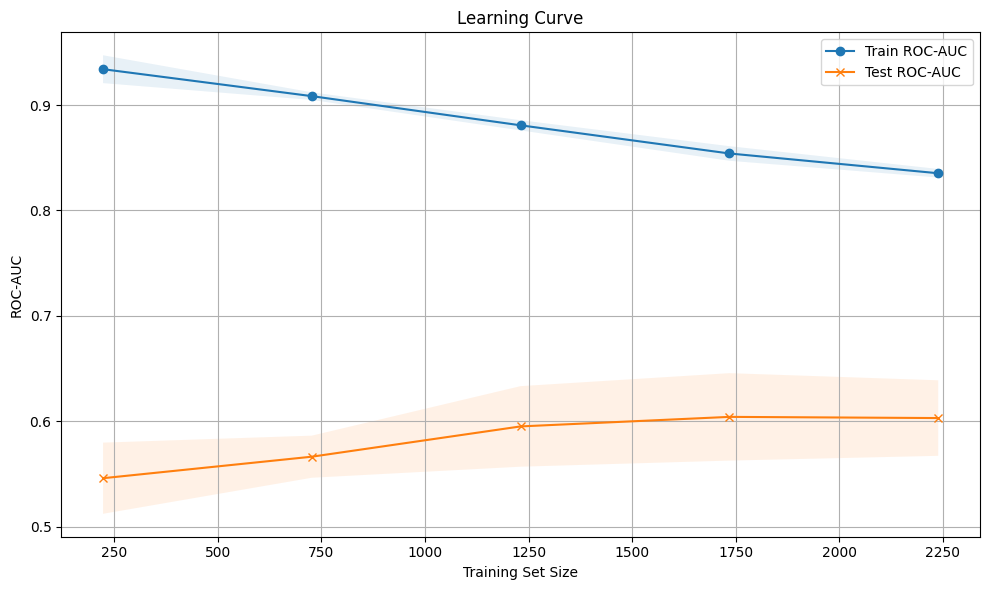

In [46]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Oversampling de clase minoritaria
X_resampled, y_resampled = mod_prep.oversample_df(
    df=model_df_nocat,
    sampling_object=SMOTE,
    random_state=0
)

# Split en train, validation y test
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(
    X_resampled,
    y_resampled,
    val_size=0.2,
    test_size=0.2,
    random_state=0,
    stratify=y_resampled
)

# Definición de parámetros a testear
params_values = {
    #"n_estimators": range(100,550,50),
    #"criterion": ["gini", "entropy", "log_loss"],
    "max_depth": range(6,21),
    #"min_samples_split": range(2, 11),
    #"min_samples_leaf": range(2, 11),
    #"max_features": [None, "sqrt", "log2", 10, 5, 2]
}

# Creación de diccionario con valores para score económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Definición del modelo base
rf_base_model = RandomForestClassifier(
    n_estimators=300,
    criterion="gini",
    max_depth=9,
    min_samples_split=6,
    min_samples_leaf=5,
    max_features=10
)

# Ploteo de curvas de aprendizaje
mod_prep.plot_learning_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=rf_base_model,
    params_dict=params_values,
    eco_score_dict=eco_score_dict)

# Tests

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# División del DataFrame en features independientes y dependiente
X = model_df_nocat.drop(columns="liked")
y = model_df_nocat["liked"]

# Pipeline con oversampler y modelo para aplicarlo en cada Fold del CV
pipeline = Pipeline([
    ("oversampler", SMOTE()),
    ("scaler", StandardScaler()),
    #("model", SVC(probability=True))
    ("model", LogisticRegression())
])

# Aplicación de cross validation y obtención de métricas
skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef Var
roc_auc,0.588310,0.016567,0.028161
accuracy,0.629868,0.013757,0.021841
precision_macro,0.560115,0.014033,0.025055
recall_macro,0.568858,0.015684,0.027572
f1_macro,0.560660,0.014957,0.026678


In [ ]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Evaluación de Oversampling

### Modelo Base

In [16]:
# Instanciación de modelo RandomForest base
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced"
)

### Evaluación de Algoritmos de Oversampling

In [34]:
# Cálculo de entropía del dataset
def calc_entropy(y):
    _, counts = np.unique(y, return_counts=True)
    prob = counts / counts.sum()
    return stats.entropy(prob, base=2)


H_set = calc_entropy(model_df_nooh["liked"])
print(H_set)

0.8348624937083953


In [35]:
# Entrenamiento y evaluación de modelo con oversampling categórico (SMOTENC)
idx_cat_features = [model_df_nooh.columns.get_loc(col) for col in pairings_list]

# Oversampling
X_smotenc, y_smotenc = mod_prep.oversample_df(
    df=model_df_nooh,
    sampling_object=SMOTENC,
    random_state=0,
    categorical_features=idx_cat_features
)

# Train test model
results_smotenc = mod_prep.train_test_model(
    X=X_smotenc,
    y=y_smotenc,
    model_object=rf_model,
    test_size=0.2,
    random_state=0,
    stratify=y_smotenc
)

# Visualización de resultados
display(Markdown("# SMOTENC"))
mod_prep.print_model_results(results_smotenc)
cm_pred = results_smotenc["cm_pred"]
eco_score = mod_prep.economic_score(
    conf_matrix=cm_pred,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

ValueError: Input contains NaN.

# SMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1644
           1       1.00      1.00      1.00      1645

    accuracy                           1.00      3289
   macro avg       1.00      1.00      1.00      3289
weighted avg       1.00      1.00      1.00      3289



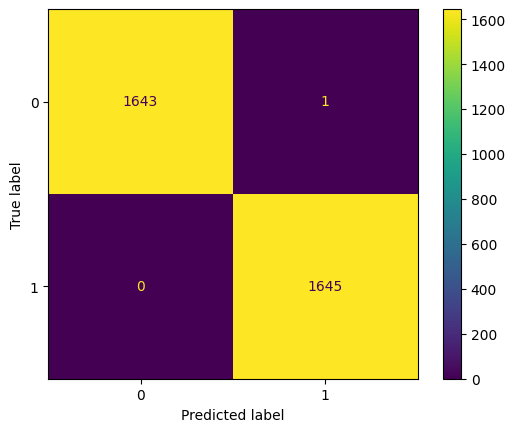

AUC Train: 0.9999998151147398

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       412
           1       0.79      0.81      0.80       411

    accuracy                           0.80       823
   macro avg       0.80      0.80      0.80       823
weighted avg       0.80      0.80      0.80       823



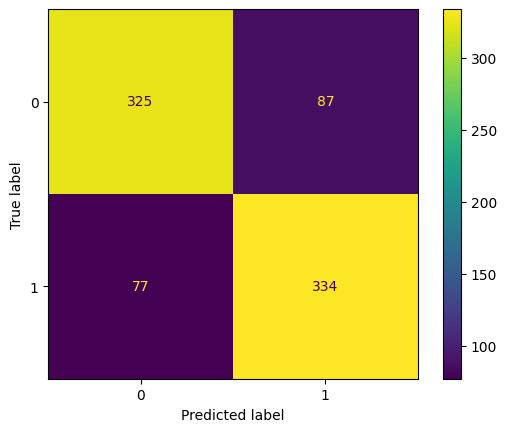

AUC Test: 0.8656928401011031
Gain from model: $7403


# ADASYN


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1488
           1       1.00      1.00      1.00      1644

    accuracy                           1.00      3132
   macro avg       1.00      1.00      1.00      3132
weighted avg       1.00      1.00      1.00      3132



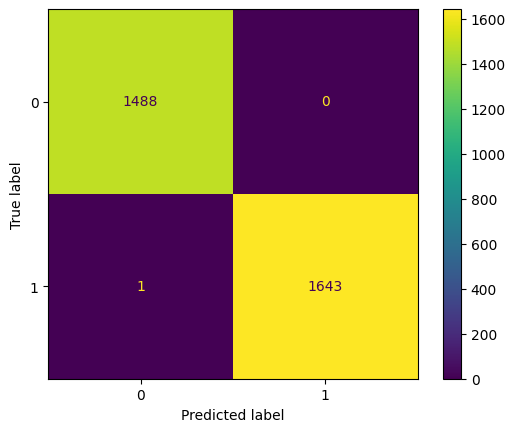

AUC Train: 0.9999997956073569

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.79      0.74      0.76       372
           1       0.78      0.83      0.80       412

    accuracy                           0.78       784
   macro avg       0.79      0.78      0.78       784
weighted avg       0.78      0.78      0.78       784



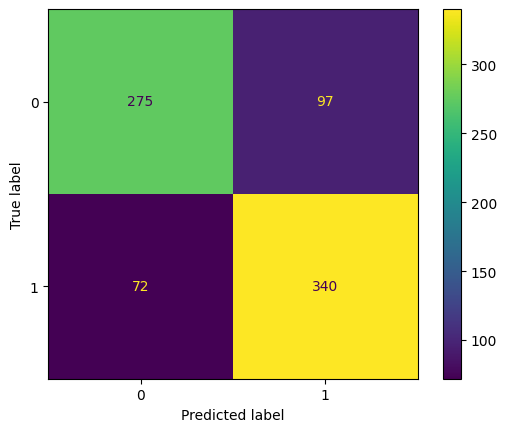

AUC Test: 0.851145735462992
Gain from model: $6918


# BorderlineSMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1644
           1       1.00      1.00      1.00      1645

    accuracy                           1.00      3289
   macro avg       1.00      1.00      1.00      3289
weighted avg       1.00      1.00      1.00      3289



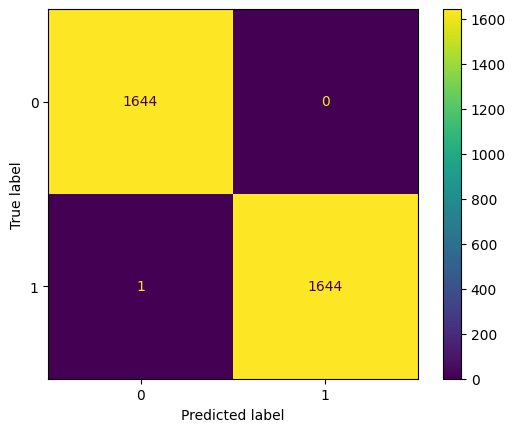

AUC Train: 0.9999998151147398

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.80      0.78      0.79       412
           1       0.79      0.81      0.80       411

    accuracy                           0.80       823
   macro avg       0.80      0.80      0.80       823
weighted avg       0.80      0.80      0.80       823



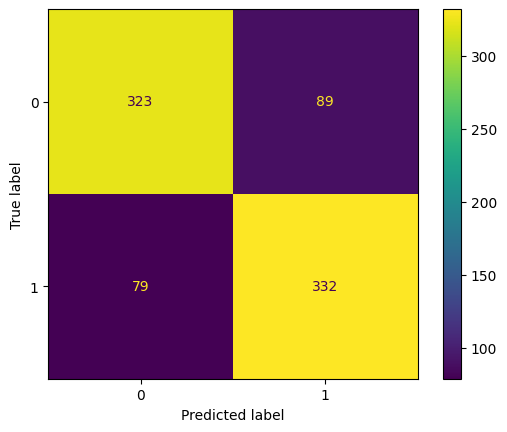

AUC Test: 0.8636583752627974
Gain from model: $7238


# SVMSMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1644
           1       1.00      1.00      1.00      1645

    accuracy                           1.00      3289
   macro avg       1.00      1.00      1.00      3289
weighted avg       1.00      1.00      1.00      3289



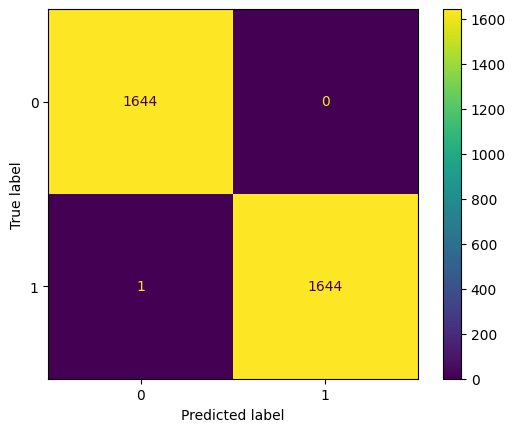

AUC Train: 0.9999998151147398

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.82      0.74      0.78       412
           1       0.76      0.84      0.80       411

    accuracy                           0.79       823
   macro avg       0.79      0.79      0.79       823
weighted avg       0.79      0.79      0.79       823



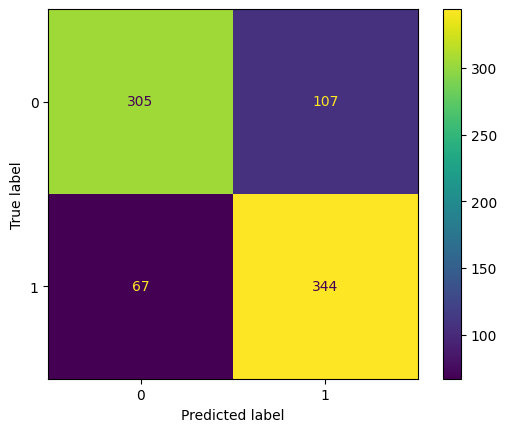

AUC Test: 0.8591760565043819
Gain from model: $6882


In [37]:
# Entrenamiento y evaluación de modelo con oversampling no categórico
sampling_objects = [SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE]

for obj in sampling_objects:
    # Oversampling
    X_resampled, y_resampled = mod_prep.oversample_df(
        df=model_df_nocat,
        sampling_object=obj,
        random_state=0,
    )
    # Train Test Model
    results_resampled = mod_prep.train_test_model(
        X=X_resampled,
        y=y_resampled,
        model_object=RandomForestClassifier(),
        test_size=0.2,
        random_state=0,
        stratify=y_resampled
    )
    # Visualización de resultados
    display(Markdown(f"# {obj.__name__}"))
    mod_prep.print_model_results(results_resampled)
    cm_pred = results_resampled["cm_pred"]
    eco_score = mod_prep.economic_score(
        conf_matrix=cm_pred,
        avg_tkt=avg_tkt,
        churn_like=churn_like,
        churn_dislike=churn_dislike
        )
    print("Gain from model: $", round(eco_score), sep="")

In [38]:
# Entropía luego de oversample
calc_entropy(y_resampled)

np.float64(1.0)

## Finetunning

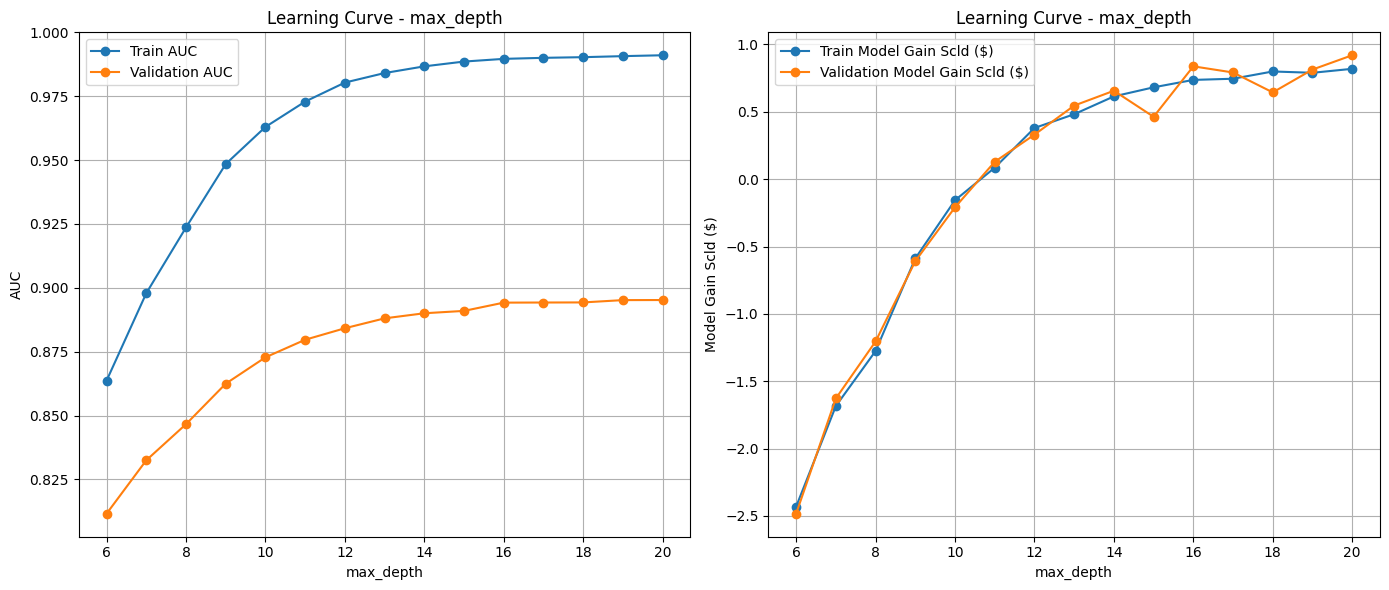

In [ ]:
# Oversampling de clase minoritaria
X_resampled, y_resampled = mod_prep.oversample_df(
    df=model_df_nocat,
    sampling_object=SMOTE,
    random_state=0
)

# Split en train, validation y test
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(
    X_resampled,
    y_resampled,
    val_size=0.2,
    test_size=0.2,
    random_state=0,
    stratify=y_resampled
)

# Definición de parámetros a testear
params_values = {
    #"n_estimators": range(100,550,50),
    #"criterion": ["gini", "entropy", "log_loss"],
    "max_depth": range(6,21),
    #"min_samples_split": range(2, 11),
    #"min_samples_leaf": range(2, 11),
    #"max_features": [None, "sqrt", "log2", 10, 5, 2]
}

# Creación de diccionario con valores para score económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Definición del modelo base
rf_base_model = RandomForestClassifier(
    n_estimators=300,
    criterion="gini",
    max_depth=9,
    min_samples_split=6,
    min_samples_leaf=5,
    max_features=10
)

# Ploteo de curvas de aprendizaje
mod_prep.plot_learning_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=rf_base_model,
    params_dict=params_values,
    eco_score_dict=eco_score_dict)

## Evaluación del modelo

In [ ]:
model_df_nocat.columns.to_list()

In [ ]:
# Oversampling de clase minoritaria
X_resampled, y_resampled = mod_prep.oversample_df(
    df=model_df_nocat,
    sampling_object=SMOTE,
    random_state=0
)

# Creación del modelo
rf_tunned_model = RandomForestClassifier(
    n_estimators=300,
    criterion="gini",
    max_depth=9,
    min_samples_split=6,
    min_samples_leaf=5,
    max_features=10
)

model_eval = mod_prep.train_val_test_model(
    X=X_resampled,
    y=y_resampled,
    model_object=rf_tunned_model,
    val_size=0.2,
    test_size=0.2,
    random_state=0,
    stratify=y_resampled
)

print("Train:\n", model_eval["train_report"], "\nVal:\n", model_eval["val_report"])

Train:
               precision    recall  f1-score   support

         0.0       0.89      0.85      0.87      3170
         1.0       0.86      0.90      0.88      3170

    accuracy                           0.87      6340
   macro avg       0.87      0.87      0.87      6340
weighted avg       0.87      0.87      0.87      6340
 
Val:
               precision    recall  f1-score   support

         0.0       0.82      0.75      0.78      1057
         1.0       0.77      0.83      0.80      1057

    accuracy                           0.79      2114
   macro avg       0.79      0.79      0.79      2114
weighted avg       0.79      0.79      0.79      2114



In [ ]:
model = RandomForestClassifier()

cv = StratifiedKFold(n_splits=5, shuffle=True)
scores = cross_validate(model, X_resampled, y_resampled, scoring=["roc_auc", "precision", "accuracy"])
scores

{'fit_time': array([3.3463769 , 2.37644553, 2.72250271, 3.12122774, 2.74699855]),
 'score_time': array([0.0747261 , 0.06561971, 0.07566094, 0.12795544, 0.07483864]),
 'test_roc_auc': array([0.57120973, 0.33811308, 0.81105689, 0.82832658, 0.78880022]),
 'test_precision': array([0.56093489, 0.1799308 , 0.92198582, 0.95061728, 0.90497738]),
 'test_accuracy': array([0.56906339, 0.41248817, 0.61258278, 0.63795551, 0.58495031])}

In [21]:
print("AUC promedio:", scores['test_roc_auc'].mean())
print("AUC desvío:", scores['test_roc_auc'].std())
print("AUC Coef Var:", scores['test_roc_auc'].std()/scores['test_roc_auc'].mean())

AUC promedio: 0.6675013006107507
AUC desvío: 0.18918513310022878
AUC Coef Var: 0.28342286813093553


# TODO:

- Rediseñá wine_score sin .max() ni .zscore, solo con diferencias directas.
- Usá sigmoid(score + ruido) para generar el prob_like.
- Generá el liked con una probabilidad, no un umbral fijo.
- Confirmá que las features de entrada del modelo no tengan lógica “futura” ni agregados post elección.
- Reentrená tus modelos con esta lógica y volvé a evaluar curvas, CV, etc.